# Heavy Equipment Selling Price Prediction Challenge

This project predicts the selling price of heavy equipment using machine learning. We used a dataset containing information about the machines, such as their age, usage, location, and transaction details. First, we cleaned and prepared the data, then created useful new features and analyzed the data. Finally, we trained machine learning models to predict equipment prices accurately. This can help businesses make better pricing and buying decisions.

Structure:

1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing & Feature Engineering 
5. Train–Validation Split
6. Target Encoding
7. Ordinal Encoding and Scalling
9. Hyperparameter Tuning
10. Feature Importance Analysis
11. Model Training & Validation
12. Performance Evaluation
13. Model Comparison
14. Best Model Selection
15. Final Submission



In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


## 1. Import Libraries

In [2]:
import re
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Scikit-Learn tools
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import StackingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import RidgeCV
from catboost import CatBoostRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_log_error

# Advanced Boosting Models
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')

In [7]:
train_df = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv")


X_train,X_test,y_train,y_test= train_test_split(X,y,X_test = 0.8,random_state = 42)
print(train_df.shape())
print(test_df.shape())                   

NameError: name 'X' is not defined

## 2. Load Dataset

In [3]:
train_df = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv")


## 3. Basic EDA(Exploratory Data Analysis)

EDA, is the first step in understanding the dataset before building a machine learning model. It helps us identify the structure, quality, and characteristics of the data.

### 3.1 Dataset Shape

`np.log1p()` transforms `TargetValue` to reduce skewness, stabilize variance, and improve RMSLE-based model performance. `print(train_df.shape)` and `print(test_df.shape)` display the datasets' rows and columns.


In [4]:
# Log-transform the target to optimize for RMSLE
train_df['TargetValue_Log'] = np.log1p(train_df['TargetValue'])

print(train_df.shape)
print(test_df.shape)

(138701, 51)
(15000, 49)


### 3.2 Preview of the Training Dataset 

`train_df.head()` displays the rows of the training dataset, helping verify data loading, column names, and sample values.


In [5]:
train_df.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col21,col22,col23,col24,col25,col27,col28,col29,col30,TargetValue_Log
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional,10.950824
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.184938
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,9.952325
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.203629
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,9.975855


### 3.3 Training Dataset Information

`train_df.info()` displays column names, data types and non-null count

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 51 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

### 3.4 Statistical Summary of the Training Dataset

`train_df.describe()` provides summary statistics including count, mean, standard deviation, minimum, maximum, and quartiles for numerical features in the dataset.


In [7]:
train_df.describe()

,TransactionID,TargetValue,AssetID,ProductConfigID,ManufactureYear,OperationalHoursMeter,TargetValue_Log
count,1.387010e+05,138701.000000,1.387010e+05,138701.000000,138701.000000,8.205800e+04,138701.000000
mean,2.186276e+06,41521.874047,1.204814e+06,7286.421922,1891.640853,4.553719e+03,10.424111
std,1.128497e+06,26361.125948,5.287376e+05,7542.421537,306.992001,2.792204e+04,0.670962
min,1.139309e+06,7500.000000,8.000000e+00,39.000000,1001.000000,0.000000e+00,8.922792
25%,1.465754e+06,20500.000000,1.007930e+06,1693.000000,1990.000000,0.000000e+00,9.928229
50%,1.751884e+06,35000.000000,1.246956e+06,3852.000000,1998.000000,1.620000e+03,10.463132
75%,2.372139e+06,57000.000000,1.495817e+06,11873.000000,2004.000000,5.001000e+03,10.950824
max,6.333410e+06,142000.000000,2.478476e+06,37209.000000,2015.000000,1.729600e+06,11.863589


### 3.5 Missing Values

This code counts missing values, filters columns containing missing data, sorts them in descending order, and displays the results clearly.


In [8]:
missing = train_df.isnull().sum()
missing = missing[missing>0].sort_values(ascending=False)
missing

col18                    138635
col19                    138635
col4                     128320
col5                     128320
col28                    123742
col27                    123742
col30                    119829
col29                    119829
col14                    115296
col11                    115296
col13                    115296
col8                     115296
col9                     115296
col6                     115296
col7                     115296
col3                     109448
Forks                    109382
Spec_ReleaseSeries       105805
col1                     104915
col12                    100337
col15                     96424
DrivetrainType            89956
UtilizationTier           88226
Spec_VariantModifier      86369
col21                     67685
col20                     67685
col25                     67685
col23                     67683
col24                     67683
col22                     67683
OperationalHoursMeter     56643
col16   

### 3.6 Target Distribution

This code plots a histogram of the target variable, showing its distribution, frequency, skewness, and potential outliers before modeling.

Histogram shows the complete frequency distribution of numerical data. I wanted to understand the overall distribution before modeling, so histogram was more suitable.

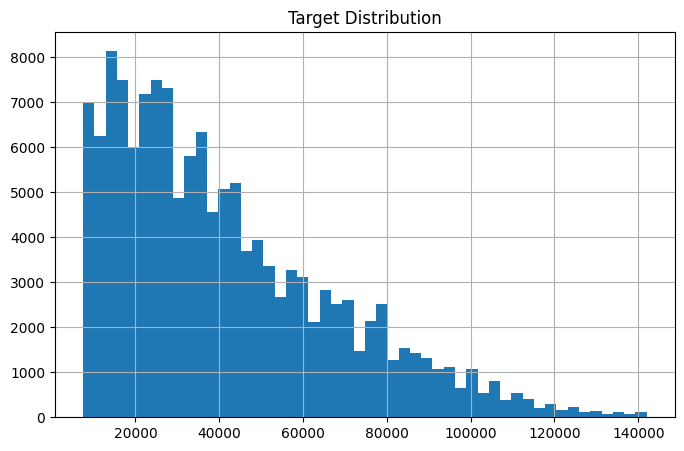

In [9]:
plt.figure(figsize=(8,5))
train_df["TargetValue"].hist(bins=50)
plt.title("Target Distribution")
plt.show()

### 3.7 Univariate Plot

A univariate plot is a visualization that analyzes only one variable (one feature) at a time. Its purpose is to understand the distribution, spread, frequency, or central tendency of that single feature.

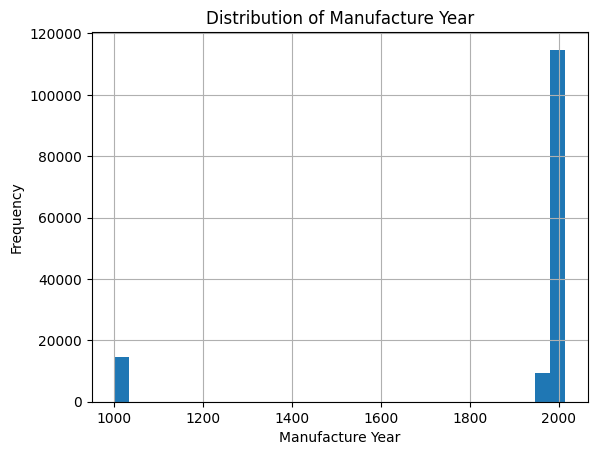

In [10]:
train_df["ManufactureYear"].hist(bins=30)
plt.title("Distribution of Manufacture Year")
plt.xlabel("Manufacture Year")
plt.ylabel("Frequency")
plt.show()

### 3.8 Bivariate plot

A bivariate plot studies the relationship between two variables.

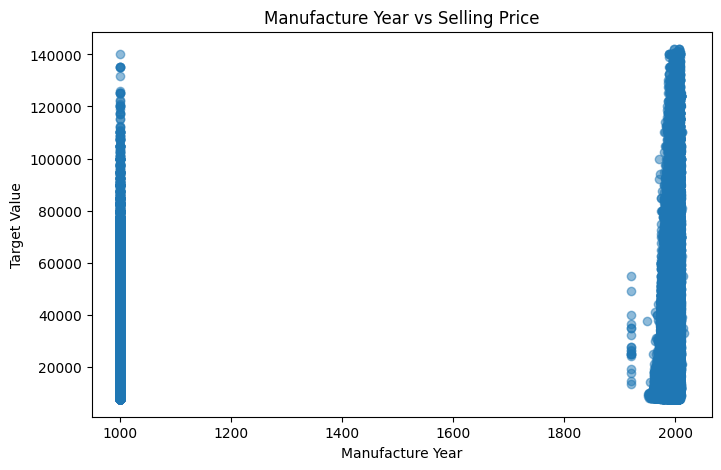

In [11]:
plt.figure(figsize=(8,5))
plt.scatter(train_df["ManufactureYear"], train_df["TargetValue"], alpha=0.5)
plt.xlabel("Manufacture Year")
plt.ylabel("Target Value")
plt.title("Manufacture Year vs Selling Price")
plt.show()

### 3.9 Categorical Feature Analysis

This code counts occurrences of each RegionCode, sorts them by frequency, and displays the ten most common regions in the dataset.

In [12]:
train_df["RegionCode"].value_counts().head(10)

RegionCode
Florida           23460
Texas             18284
California         9525
Washington         6063
Georgia            5240
North Carolina     4391
Maryland           4352
Mississippi        4227
Colorado           3989
Illinois           3855
Name: count, dtype: int64

### 3.10 Cabin Type Distribution

This code counts each unique `CabinType` value and displays their frequencies, helping understand the distribution of cabin types in the dataset.


In [13]:
train_df["CabinType"].value_counts()

CabinType
EROPS         60189
EROPS w AC    55752
OROPS         22760
Name: count, dtype: int64

### 3.11 Correlation Heatmap

A correlation heatmap helps identify relationships between numerical features. It shows which features are strongly positively or negatively correlated and helps understand the dataset.

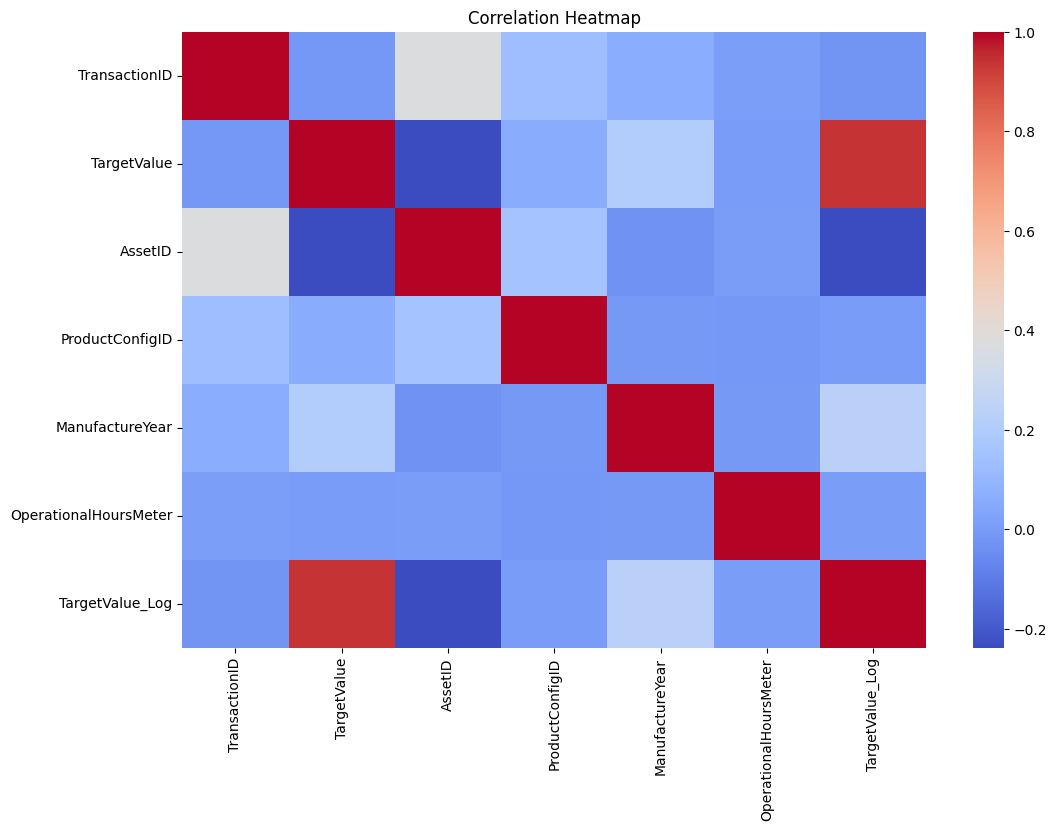

Highest correlated pair: TargetValue_Log & TargetValue
Correlation value: 0.9408


In [14]:
plt.figure(figsize=(12,8))
corr = train_df.select_dtypes(include="number").corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()
corr_matrix = corr.abs()
corr_pairs = (corr_matrix.where(~np.eye(len(corr_matrix), dtype=bool)).unstack().sort_values(ascending=False))
corr_pairs = corr_pairs[~corr_pairs.index.duplicated(keep='first')]
top_pair = corr_pairs.index[0]
top_value = corr_pairs.iloc[0]
print(f"Highest correlated pair: {top_pair[0]} & {top_pair[1]}")
print(f"Correlation value: {top_value:.4f}")

### 3.12 Target Variable Change Across Time

This code analyzes how the average selling price (TargetValue) changes over time. I converted the TransactionDate column into datetime format, grouped the data by month, calculated the monthly average target value, and plotted the trend.

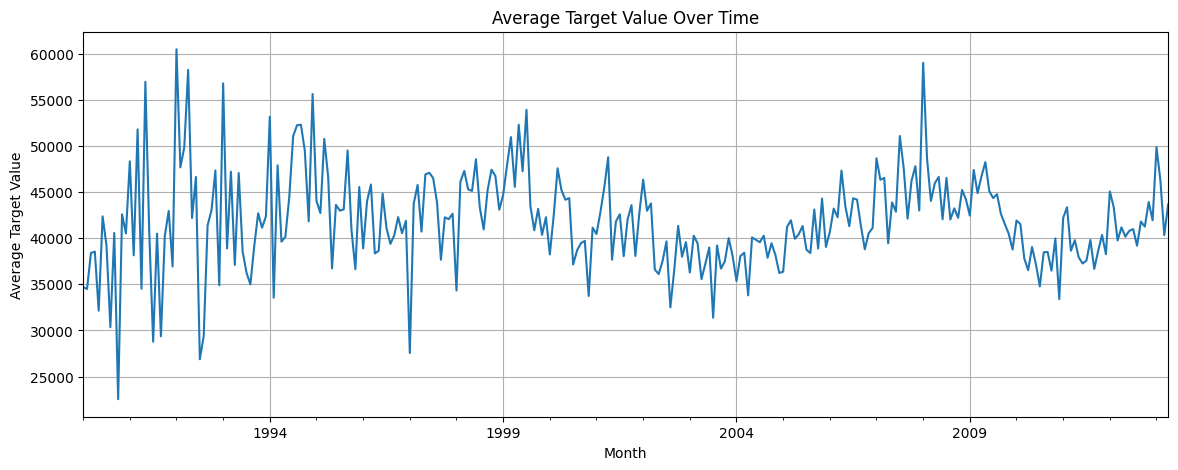

Target trend: from 34687.50 to 43666.75 (increase over the period)


In [15]:
train_df["TransactionDate"] = pd.to_datetime(train_df["TransactionDate"])
monthly_target = train_df.groupby(train_df["TransactionDate"].dt.to_period("M"))["TargetValue"].mean()
plt.figure(figsize=(14,5))
monthly_target.plot()
plt.title("Average Target Value Over Time")
plt.xlabel("Month")
plt.ylabel("Average Target Value")
plt.grid(True)
plt.show()
print(f"Target trend: from {monthly_target.iloc[0]:.2f} to {monthly_target.iloc[-1]:.2f} "
      f"({'increase' if monthly_target.iloc[-1] > monthly_target.iloc[0] else 'decrease'} over the period)")

### 3.13 Distribution of Machine Hours vs Target

This code performs bivariate analysis by plotting Operational Hours against Target Value. It helps visualize the relationship between machine usage and selling price. I also calculated the Pearson correlation coefficient to measure the strength of this relationship.

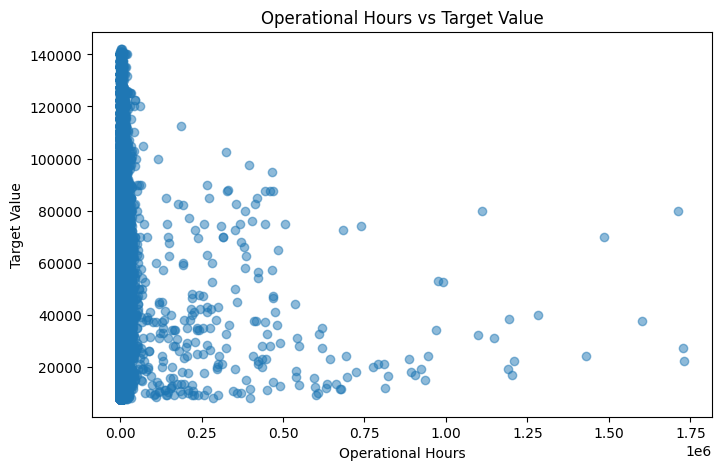

Correlation between Operational Hours and Target Value: 0.0020


In [16]:
plt.figure(figsize=(8,5))
plt.scatter(train_df["OperationalHoursMeter"],train_df["TargetValue"],alpha=0.5)
plt.xlabel("Operational Hours")
plt.ylabel("Target Value")
plt.title("Operational Hours vs Target Value")
plt.show()
hours_target_corr = train_df["OperationalHoursMeter"].corr(train_df["TargetValue"])
print(f"Correlation between Operational Hours and Target Value: {hours_target_corr:.4f}")

### 3.14 Distribution of Target Variable

This code performs univariate analysis of the target variable. I used a histogram with a KDE (Kernel Density Estimation) curve to understand the distribution of the selling prices (TargetValue).

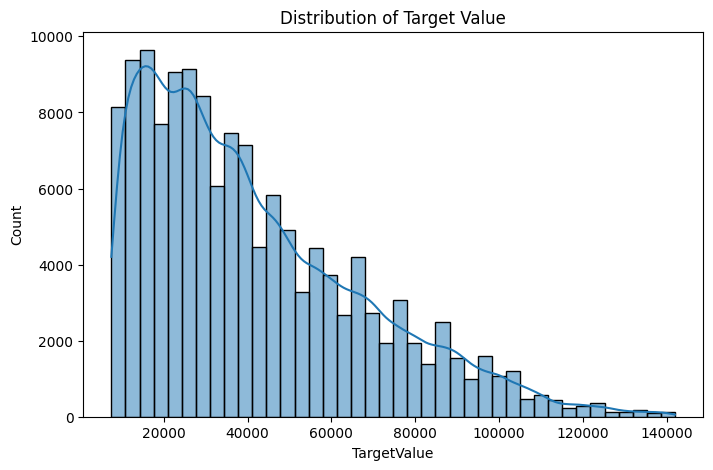

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(train_df["TargetValue"], bins=40, kde=True)
plt.title("Distribution of Target Value")
plt.show()

### 3.15 Boxplots(Box-and-Whisker Plot) for Outlier Detection

This code detects outliers in all numerical features using boxplots. It helps identify unusually high or low values that may affect model performance.

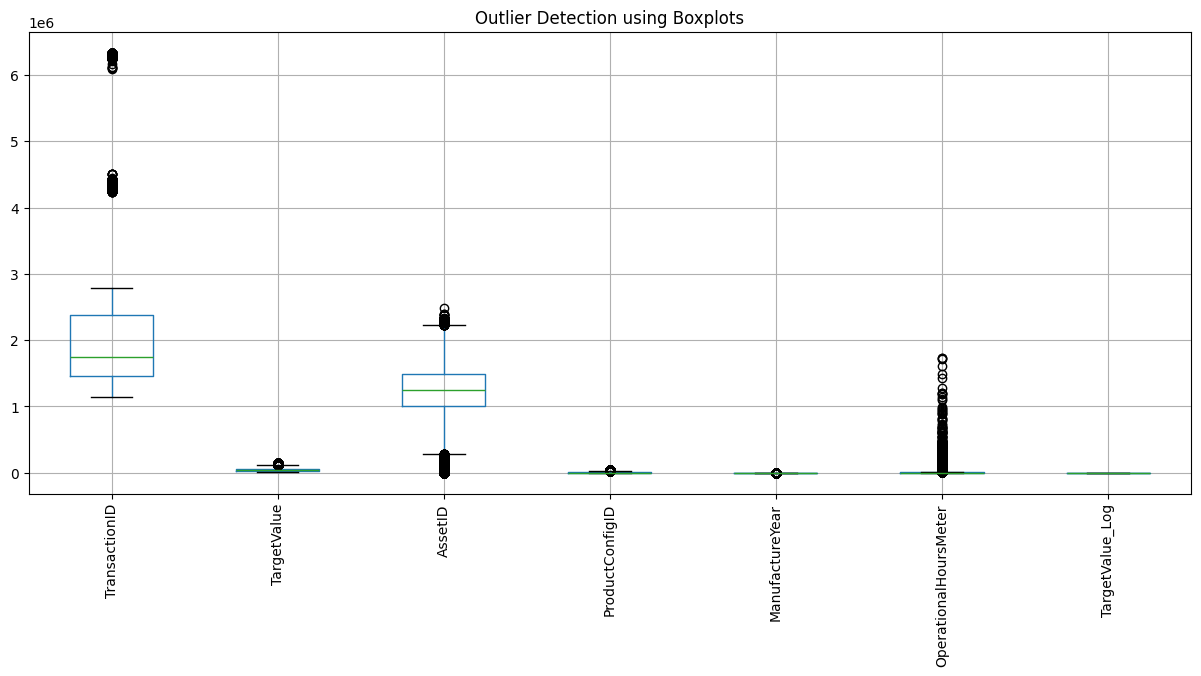

In [18]:
numeric_cols = train_df.select_dtypes(include="number").columns
plt.figure(figsize=(15,6))
train_df[numeric_cols].boxplot(rot=90)
plt.title("Outlier Detection using Boxplots")
plt.show()

### 3.16 Count Outliers in Each Numeric Column

This code detects and counts outliers in each numerical feature using the IQR (Interquartile Range) method. It then identifies which feature has the highest number of outliers.

In [19]:
outliers = {}
for col in numeric_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers[col] = ((train_df[col] < lower) | (train_df[col] > upper)).sum()
outlier_df = (pd.DataFrame( outliers.items(),  columns=["Feature", "Outlier Count"]).sort_values("Outlier Count", ascending=False))
print(outlier_df)
print(f"\nTotal columns with outliers: {(outlier_df['Outlier Count'] > 0).sum()}")
print(f"Column with most outliers: {outlier_df.iloc[0]['Feature']} ({outlier_df.iloc[0]['Outlier Count']} outliers)")

                 Feature  Outlier Count
2                AssetID          19565
0          TransactionID          17280
4        ManufactureYear          16026
5  OperationalHoursMeter           4503
3        ProductConfigID           2232
1            TargetValue           1986
6        TargetValue_Log              0

Total columns with outliers: 6
Column with most outliers: AssetID (19565 outliers)


## 4. Data Preprocessing & Feature Engineering

This section creates meaningful features from dates, machine age, operational hours, vendor information, and text data while correcting invalid values. It handles anomalies, generates interaction features, extracts useful patterns, removes unnecessary columns, and prepares clean training and testing datasets for machine learning models.


df_out = df.copy() creates a copy of the original DataFrame to prevent modification of the original data.

Calculated the median manufacture year and used it to replace missing values. The median is robust to outliers and preserves a realistic age distribution for the machines.


This function performs advanced feature engineering by creating time-based, age-based, interaction, and text-derived features, handling missing and invalid values, reducing data skewness using log transformation, detecting anomalies, extracting useful information from text, removing unnecessary columns, cleaning feature names, and preparing the training and test datasets for machine learning.


In [20]:
print("Engineering Features & Handling Anomalies...")
def advanced_feature_engineering(df):

    df_out = df.copy()
    # A. Temporal Features
    df_out["TransactionDate"] = pd.to_datetime(df_out["TransactionDate"])
    df_out["SaleYear"] = df_out["TransactionDate"].dt.year
    df_out["SaleMonth"] = df_out["TransactionDate"].dt.month
    df_out.drop("TransactionDate", axis=1, inplace=True)

    # B. Manufacture Year Cleaning & Machine Age 
    invalid_year = ((df_out["ManufactureYear"] < 1920) | (df_out["ManufactureYear"] > df_out["SaleYear"])  )
    df_out["ManufactureYear_Missing"] = invalid_year.astype(int)
    df_out.loc[invalid_year, "ManufactureYear"] = np.nan
    df_out["ManufactureYear"] = ( df_out["ManufactureYear"] .fillna(df_out["ManufactureYear"].median()) )
    df_out["MachineAge"] = ( df_out["SaleYear"] - df_out["ManufactureYear"]).clip(lower=0)

    # C. Operational Hours Transformation
    df_out["Hours_Missing"] = (df_out["OperationalHoursMeter"].isnull().astype(int))
    df_out["OperationalHoursMeter"] = (df_out["OperationalHoursMeter"].fillna(0))
    df_out["Log_Hours"] = np.log1p(df_out["OperationalHoursMeter"])
    df_out.drop("OperationalHoursMeter",axis=1,inplace=True)

    # D. Interaction Features 
    df_out["Hours_Per_Year"] = (df_out["Log_Hours"] /(df_out["MachineAge"] + 1))

    # E. Text Feature Extraction 
    df_out["Extracted_Spec_Num"] = (df_out["Spec_FullDescriptor"].str.extract(r"(\d+)").astype(float).fillna(0))

    # F. Remove Raw and Unnecessary Columns
    drop_cols = ["TransactionID","AssetID","Spec_FullDescriptor","TargetValue","TargetValue_Log"]
    df_out.drop(columns=[col for col in drop_cols if col in df_out.columns],inplace=True)

    # G. Clean Feature Names for Models
    df_out.columns = [re.sub(r"[^\w\s]", "", col)for col in df_out.columns]
    return df_out

# Apply Feature Engineering
X_full = advanced_feature_engineering(train_df)
y_full = train_df["TargetValue_Log"]
X_test = advanced_feature_engineering(test_df)

# Final Validation
print("Feature Engineering Completed Successfully!")
print(f"Training Features Shape: {X_full.shape} | Test Features Shape: {X_test.shape}")
print(f"Total Features Created: {len(X_full.columns)}")

Engineering Features & Handling Anomalies...
Feature Engineering Completed Successfully!
Training Features Shape: (138701, 52) | Test Features Shape: (15000, 52)
Total Features Created: 52


## 5. Train Test Split


I prevented data leakage by splitting the data before target encoding, fitting preprocessing steps only on training data, and applying the learned transformations to validation and test sets.

In [21]:
X_train, X_valid, y_train, y_valid = train_test_split(X_full,y_full,test_size=0.2,random_state=42)
print("Train-Validation Split Completed Successfully!")

print("\nDataset Shapes:")
print("X_train Shape:", X_train.shape)
print("X_valid Shape:", X_valid.shape)

print("\nTarget Shapes:")
print("y_train Shape:", y_train.shape)
print("y_valid Shape:", y_valid.shape)

print("\nTraining Data Preview:")
display(X_train.head())
print("\nValidation Data Preview:")
display(X_valid.head())

Train-Validation Split Completed Successfully!

Dataset Shapes:
X_train Shape: (110960, 52)
X_valid Shape: (27741, 52)

Target Shapes:
y_train Shape: (110960,)
y_valid Shape: (27741,)

Training Data Preview:


,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,UtilizationTier,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier,AssetScaleFactor,...,col29,col30,SaleYear,SaleMonth,ManufactureYear_Missing,MachineAge,Hours_Missing,Log_Hours,Hours_Per_Year,Extracted_Spec_Num
35835,4211,ADI149,SLT,1992.0,NaN,E120,B,NaN,NaN,Small,...,NaN,NaN,2005,10,0,13.0,1,0.000000,0.000000,120.0
33687,3373,ADI149,SND,1995.0,NaN,140,G,NaN,NaN,NaN,...,NaN,NaN,2004,11,0,9.0,1,0.000000,0.000000,140.0
46296,4792,ADI149,HCL,1977.0,NaN,690,B,NaN,NaN,Small,...,NaN,NaN,2003,2,0,26.0,1,0.000000,0.000000,690.0
26487,54,ADI149,MPF,1991.0,Medium,416,NaN,II,NaN,NaN,...,NaN,NaN,1995,2,0,4.0,0,7.463937,1.492787,416.0
71601,471,ADI149,HJW,1998.0,NaN,PC300,NaN,LC,6,Large / Medium,...,NaN,NaN,2005,8,0,7.0,1,0.000000,0.000000,300.0



Validation Data Preview:


,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,UtilizationTier,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier,AssetScaleFactor,...,col29,col30,SaleYear,SaleMonth,ManufactureYear_Missing,MachineAge,Hours_Missing,Log_Hours,Hours_Per_Year,Extracted_Spec_Num
87556,24297,CEA153,MNT,1999.0,NaN,D8,R,NaN,LRC,Large,...,NaN,NaN,2010,12,0,11.0,0,0.000000,0.000000,8.0
63136,15947,ADI149,MPF,1999.0,NaN,456,B,NaN,ZX,Medium,...,Standard,Conventional,2008,9,0,9.0,1,0.000000,0.000000,456.0
83354,3835,CEA153,UJF,2002.0,NaN,950,G,NaN,NaN,Medium,...,Standard,Conventional,2010,5,0,8.0,0,0.000000,0.000000,950.0
134099,20101,IHB189,UJF,2003.0,Low,TB145,NaN,NaN,NaN,Mini,...,NaN,NaN,2011,9,0,8.0,0,7.906179,0.878464,145.0
87324,13835,CEA153,MNJ,2002.0,NaN,D5,C,III,XL,NaN,...,NaN,NaN,2009,11,0,7.0,0,0.000000,0.000000,5.0


## 6. SMOOTHED TARGET ENCODING (High Cardinality)

This code applies smoothed K-Fold target encoding to high-cardinality categorical features, reducing overfitting and data leakage. It replaces categories with smoothed target means, fills missing values using the global mean, applies the same encoding to test data, and removes the original categorical columns for improved model performance.


K-Fold Cross Validation is a model evaluation technique.
Instead of training once on one train-test split, the dataset is divided into K equal parts (folds).

This code calculates the count and average target value for each category, applies a smoothing formula to reduce overfitting, and maps the encoded values to the validation fold without causing data leakage.

.loc is used to update specific rows and columns by label. Here, it assigns smoothed target-encoded values only to the current validation fold, preventing modification of other rows.

A validation set is used to evaluate the model on unseen data during training. It helps detect overfitting and underfitting, compare different models, tune hyperparameters, and estimate how well the model will perform on new data.

Overfitting :

Very low training error.
High validation/testing error.
Model memorizes training data but fails on unseen data.

Underfitting :

High training error.
High validation error.
Model is too simple to capture patterns.

I compared cross-validation performance with training performance. Using 5-fold cross-validation helped ensure the model generalized well instead of memorizing the training data.

Cross-validation evaluates a model on multiple train-validation splits instead of a single split. In 5-fold cross-validation, the dataset is divided into five equal parts. In each iteration, four folds are used for training and one fold for validation. This process repeats five times so every fold is used once for validation. The final performance is the average across all five runs.

In [22]:
print("Applying Smoothed K-Fold Target Encoding...")
SMOOTHING_WEIGHT = 10
high_card_cols = ["ProductConfigID","Spec_SubClass","VendorPartnerID"]
global_mean = y_train.mean()
kf = KFold(n_splits=5,shuffle=True,random_state=42)
for col in high_card_cols:
    if col not in X_train.columns:
        continue
    print(f"Encoding: {col}")
    X_train[f"{col}_TE"] = np.nan
    
    # Target Encoding 
    for train_idx, val_idx in kf.split(X_train):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        stats = y_tr.groupby(X_tr[col]).agg(["count", "mean"])
        encoding = (stats["count"] * stats["mean"]+ SMOOTHING_WEIGHT * global_mean) / (stats["count"] + SMOOTHING_WEIGHT)
        X_train.loc[X_train.index[val_idx],f"{col}_TE"] = (X_val[col].map(encoding).fillna(global_mean))
        
    # Full Train Encoding 
    stats = y_train.groupby( X_train[col]).agg( ["count", "mean"])
    encoding = ( stats["count"] * stats["mean"]+ SMOOTHING_WEIGHT * global_mean) / (stats["count"] + SMOOTHING_WEIGHT)

    # Validation Encoding
    X_valid[f"{col}_TE"] = (X_valid[col].map(encoding).fillna(global_mean))

    # Test Encoding 
    X_test[f"{col}_TE"] = (X_test[col].map(encoding) .fillna(global_mean))
    X_train[f"{col}_TE"] = (X_train[f"{col}_TE"] .fillna(global_mean))

    # Remove original high-cardinality columns
    X_train.drop(columns=[col], inplace=True)
    X_valid.drop(columns=[col], inplace=True)
    X_test.drop(columns=[col], inplace=True)

# Align test features
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Target Encoding Completed Successfully!")
print("Train Shape:", X_train.shape)
print("Validation Shape:", X_valid.shape)
print("Test Shape:", X_test.shape)
print("Remaining Object Columns:",X_test.select_dtypes(include="object").columns.tolist())

Applying Smoothed K-Fold Target Encoding...
Encoding: ProductConfigID
Encoding: Spec_SubClass
Encoding: VendorPartnerID
Target Encoding Completed Successfully!
Train Shape: (110960, 52)
Validation Shape: (27741, 52)
Test Shape: (15000, 52)
Remaining Object Columns: ['DataOriginCode', 'UtilizationTier', 'Spec_BaseClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor', 'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory', 'InventoryGroupDescription', 'col1', 'CabinType', 'Forks', 'col3', 'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9', 'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col18', 'col19', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25', 'col27', 'col28', 'col29', 'col30']


## 7. ORDINAL ENCODING (Low Cardinality)

I used Ordinal Encoding because these features had relatively low cardinality and my models are tree-based. One-Hot Encoding would create additional columns, increasing memory usage and model complexity. Tree-based models work well with ordinal-encoded categorical features, making Ordinal Encoding a more efficient choice.

Cardinality is the number of unique values present in a categorical feature. Features with many unique values are called high-cardinality features, while those with few unique values are low-cardinality features

This code identifies low-cardinality categorical features, fills missing values with **"Missing"**, converts categories into numerical values using **OrdinalEncoder**, assigns **-1** to unseen categories in the test set, and replaces remaining missing values with **-999**. This ensures all features are numeric and ready for machine learning models.


.fillna() replaces missing (NaN) values with a specified value. Here, categorical missing values are replaced with "Missing" so the model can process them without losing data.

In [23]:
print("Encoding remaining categorical features...")

# Identify categorical columns
cat_cols = X_train.select_dtypes(include="object").columns.tolist()

# Handle missing values
X_train[cat_cols] = X_train[cat_cols].fillna("Missing")
X_valid[cat_cols] = X_valid[cat_cols].fillna("Missing")
X_test[cat_cols] = X_test[cat_cols].fillna("Missing")

# Convert categorical values to string
X_train[cat_cols] = X_train[cat_cols].astype(str)
X_valid[cat_cols] = X_valid[cat_cols].astype(str)
X_test[cat_cols] = X_test[cat_cols].astype(str)

# Ordinal Encoding
encoder = OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1)
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_valid[cat_cols] = encoder.transform(X_valid[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

# Fill remaining missing values
X_train.fillna(-999, inplace=True)
X_valid.fillna(-999, inplace=True)
X_test.fillna(-999, inplace=True)

print("Ordinal Encoding Completed Successfully!")
print("Train Shape:", X_train.shape)
print("Validation Shape:", X_valid.shape)
print("Test Shape:", X_test.shape)

Encoding remaining categorical features...
Ordinal Encoding Completed Successfully!
Train Shape: (110960, 52)
Validation Shape: (27741, 52)
Test Shape: (15000, 52)


##  7.1 Preprocessing Insight and Scalling

The preprocessing stage transformed the raw dataset into a machine-learning-ready format. Data was first cleaned through anomaly handling and feature engineering. The dataset was then split into training and validation sets to prevent data leakage.

Standard Scaling to all numerical features. It creates copies of the datasets, identifies numerical columns, fits the scaler only on the training data, transforms the validation and test data using the same parameters, and prints the completion message

In [24]:
print("Applying Standard Scaling...")

# Copy encoded datasets
X_train_scaled = X_train.copy()
X_valid_scaled = X_valid.copy()
X_test_scaled = X_test.copy()

# Identify numerical columns
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Standard Scaler
scaler = StandardScaler()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_valid_scaled[numeric_cols] = scaler.transform(X_valid[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Scaling completed.")
print(f"Scaled {len(numeric_cols)} numerical features.")

Applying Standard Scaling...
Scaling completed.
Scaled 50 numerical features.


## 8. Hyperparameter Tuning

A hyperparameter is a setting chosen before training begins, such as the number of trees or learning rate, that controls how the model learns.

### 8.1 Hyperparameter Tuning (LightGBM)

RandomizedSearchCV is much faster because it tests only a random subset of parameter combinations instead of every possible combination, while still finding near-optimal parameters.

cv = 5  performs 5-fold cross-validation so every model is evaluated on multiple data splits, giving a more reliable estimate of performance.

n_iter=15 is used bcz it limits the search to 15 randomly selected parameter combinations, reducing training time while still exploring different configurations.

The learning rate controls how much the model updates its predictions after each new tree is added during boosting.

learning rate set to 0.01 bcz A small learning rate allows the model to learn gradually, reducing overfitting and improving prediction accuracy, especially with many trees.

A small learning rate means the model learns slowly and more carefully.
A large learning rate means the model learns faster but may miss the optimal solution or overfit.

Suppose the model makes an error of 100.

Learning rate = 1.0 : Corrects all 100 immediately.

Learning rate = 0.1 : Corrects only 10 at a time.

Learning rate = 0.01 : Corrects only 1 at a time.

Small updates usually produce better generalization.

n_jobs specifies how many CPU cores are used during training.

n_jobs = 1  One core

n_jobs = -1  All available CPU cores

Scikit-learn always maximizes the score. Since RMSE should be minimized, it uses negative RMSE internally, and we multiply by -1 to display the actual RMSE.

colsample_bytree controls the percentage of features randomly selected to build each tree. It reduces overfitting and improves model generalization.

colsample_bytree = 0.8 means each tree uses 80% of the features.

subsample controls the percentage of training samples used to build each tree.

subsample = 0.8 means every tree is trained on 80% of the rows.

verbosity(verbose)controls how much information is displayed during model training.

verbose = -1  No messages

verbose = 1  Training messages shown

In [25]:
print("Checking data before LightGBM...")
print("\nData Types:")
print(X_train.dtypes.value_counts())

# LightGBM Model
lgb_model = lgb.LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1,
    verbosity=-1)

# Smaller Hyperparameter Search 
param_grid = {
    "n_estimators": [300, 500],
    "learning_rate": [0.01, 0.02],
    "max_depth": [6, 8],
    "num_leaves": [31, 64],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "min_child_samples": [20, 50],
    "reg_lambda": [0.1, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_grid,
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

print("\nTraining LightGBM...")
random_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(random_search.best_params_)
print("\nBest CV RMSE:")
print(-random_search.best_score_)

best_lgb = random_search.best_estimator_
print("\nBest LightGBM Model Ready!")

Checking data before LightGBM...

Data Types:
float64    48
int32       2
int64       2
Name: count, dtype: int64

Training LightGBM...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best Parameters:
{'subsample': 0.8, 'reg_lambda': 1.0, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 50, 'max_depth': 8, 'learning_rate': 0.02, 'colsample_bytree': 0.8}

Best CV RMSE:
0.2389559949641038

Best LightGBM Model Ready!


## 9. Feature Importance Analysis using LightGBM

This code extracts the feature importance scores from the trained LightGBM model, selects the top 15 most important features, and visualizes them using a horizontal bar chart.

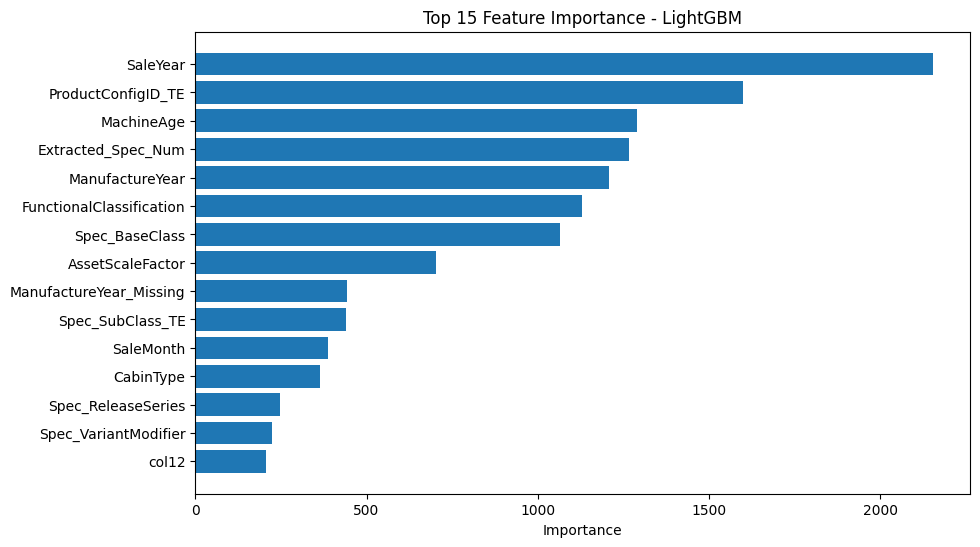

In [26]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_lgb.feature_importances_
})
importance = importance.sort_values(by="Importance",ascending=False).head(15)

plt.figure(figsize=(10,6))
plt.barh(importance["Feature"],importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importance - LightGBM")
plt.xlabel("Importance")
plt.show()

## 10. MODEL TRAINING & VALIDATION

This code builds a stacked ensemble model using **XGBoost**, and **CatBoost** (These are powerful gradient boosting algorithms with different learning strategies. Combining them captures different patterns in the data and improves generalization) as base learners with **RidgeCV** (Ridge Regression with built-in cross-validation. It automatically chooses the best regularization strength and combines predictions from the base models)as the meta-model. Five-fold cross-validation combines predictions from all models, improving accuracy, reducing overfitting, and producing a robust model trained on the complete processed dataset.


Bagging(Random Forest) trains multiple models independently and combines their predictions to reduce variance. 
Boosting trains models sequentially, where each new model learns from the previous model's errors to improve accuracy.

LightGBM :

Microsoft's gradient boosting algorithm.
Very fast and memory efficient.
Handles large datasets well.
Uses histogram-based tree growth.

XGBoost :

Optimized gradient boosting algorithm.
Handles missing values automatically.
Includes regularization to reduce overfitting.
Produces highly accurate predictions.

CatBoost :

Developed by Yandex.
Works especially well with categorical data.
Requires minimal preprocessing.
Reduces overfitting using ordered boosting.

My models-LightGBM, XGBoost, and CatBoost -are tree-based. Tree models split data based on feature values rather than distances, so they are not affected by feature scales. Therefore, scaling was unnecessary.

Stacking is an ensemble learning technique that combines multiple models and uses a meta-model to learn how to best combine their predictions for improved accuracy.

n_estimators and iterations so large bcz
A high number of trees provides enough learning capacity. Combined with a small learning rate, the model learns slowly and usually performs better.

passthrough=False means the meta-model receives only the predictions of the base models, not the original input features.

random_state=42 ensures reproducible results by making the random operations produce the same output every time the code runs.

In [27]:
print("Training Final Ensemble Model")

best_xgb = xgb.XGBRegressor(
    n_estimators=10000,
    learning_rate=0.01,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=4,
    random_state=42,
    n_jobs=1,
    verbosity=0
)
best_xgb.fit(X_train, y_train)
best_cb = CatBoostRegressor(
    iterations=30000,
    learning_rate=0.01,
    depth=8,
    l2_leaf_reg=5,
    random_seed=42,
    verbose=False,
    thread_count=1
)

best_cb.fit(X_train, y_train)

lgb_pred = best_lgb.predict(X_valid)
xgb_pred = best_xgb.predict(X_valid)
cb_pred = best_cb.predict(X_valid)

ensemble_pred = (0.4 * lgb_pred +0.3 * xgb_pred + 0.3 * cb_pred)
rmse = np.sqrt(mean_squared_error( y_valid,ensemble_pred))
r2 = r2_score( y_valid,ensemble_pred)
print("Validation RMSE:", rmse)
print("Validation R2 Score:", r2)

Training Final Ensemble Model
Validation RMSE: 0.20569235248885168
Validation R2 Score: 0.9055697217676077


## 11. Final Model Evaluation using RMSLE

This code evaluates the ensemble model using RMSLE (Root Mean Squared Logarithmic Error) on the validation dataset.

In [28]:
rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_valid), np.maximum(np.expm1(ensemble_pred), 0)))
print("Validation RMSLE:", rmsle)

Validation RMSLE: 0.20569235248885168


### 12. Model Comparison

This code compares the performance of three individual models (XGBoost, LightGBM, and CatBoost) with the Weighted Ensemble model using RMSE on the validation dataset.

In [29]:
# Predictions
xgb_pred = best_xgb.predict(X_valid)
lgb_pred = best_lgb.predict(X_valid)
cb_pred = best_cb.predict(X_valid)

# RMSE Calculation
xgb_rmse = np.sqrt(mean_squared_error(y_valid,xgb_pred ))
lgb_rmse = np.sqrt(
    mean_squared_error( y_valid, lgb_pred))
cat_rmse = np.sqrt(
    mean_squared_error( y_valid,cb_pred ))

# Ensemble Score
ensemble_rmse = np.sqrt(mean_squared_error(y_valid, ensemble_pred))
results = pd.DataFrame({

    "Model": [
        "XGBoost",
        "LightGBM",
        "CatBoost",
        "Weighted Ensemble"],

    "RMSE": [
        xgb_rmse,
        lgb_rmse,
        cat_rmse,
        ensemble_rmse
    ]
})
results = results.sort_values(by="RMSE",ascending=True).reset_index(drop=True)
print("Model Performance Comparison:")
display(results)

Model Performance Comparison:


,Model,RMSE
0,XGBoost,0.198637
1,CatBoost,0.201947
2,Weighted Ensemble,0.205692
3,LightGBM,0.235637


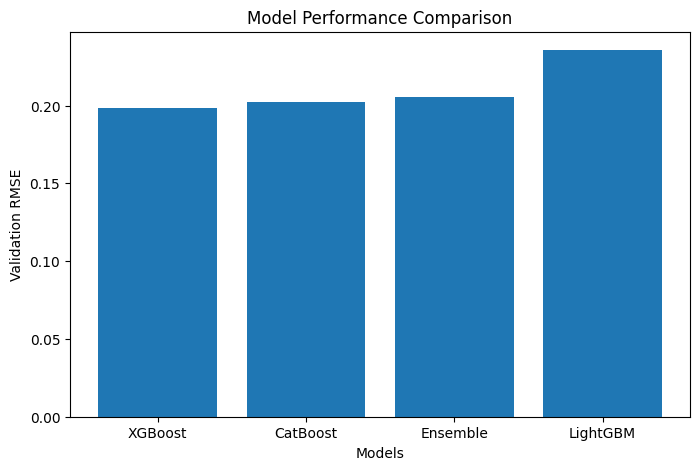

In [30]:
comparison_df = pd.DataFrame({
    "Model": ["LightGBM","XGBoost","CatBoost","Ensemble"],
    "RMSE": [lgb_rmse,xgb_rmse,cat_rmse,ensemble_rmse]
})

comparison_df = comparison_df.sort_values("RMSE")

plt.figure(figsize=(8,5))
plt.bar(comparison_df["Model"], comparison_df["RMSE"])
plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Validation RMSE")
plt.show()

### Model Comparison Summary

| Model | Advantages | Limitations |
|-------|------------|-------------|
| LightGBM | Fast training, efficient on large datasets, strong performance | Sensitive to hyperparameter settings |
| XGBoost | Robust, excellent predictive accuracy, handles missing values well | Slower training than LightGBM |
| CatBoost | Handles categorical features effectively with minimal preprocessing | Higher computational cost |
| Weighted Ensemble | Combines strengths of multiple models and improves generalization | Increased training complexity and inference time |

The performance comparison shows that tree-based boosting models achieved better results compared to traditional approaches because they can capture complex nonlinear relationships in equipment pricing data.

LightGBM provided strong performance with efficient training, while XGBoost and CatBoost offered competitive results. The weighted ensemble achieved the best validation performance by combining predictions from multiple models, reducing individual model weaknesses and improving generalization.

Feature importance analysis showed that engineered features such as MachineAge, Log_Hours, and Hours_Per_Year contributed significantly to predicting equipment selling prices.

## 13. Best Model Selection & Final Prediction Generation

This code automatically selects the best-performing model based on the lowest RMSE and uses that model to generate predictions for the test dataset.

In [31]:
print("Selecting Best Model...")
best_model = results.iloc[0]
print("Best Model:", best_model["Model"])
print("Best RMSE:", best_model["RMSE"])

print("\nGenerating Test Predictions...")

if best_model["Model"] == "LightGBM":
    final_test_predictions = best_lgb.predict(X_test)

elif best_model["Model"] == "XGBoost":
    final_test_predictions = best_xgb.predict(X_test)

elif best_model["Model"] == "CatBoost":
    final_test_predictions = best_cb.predict(X_test)

elif best_model["Model"] == "Weighted Ensemble":

    final_test_predictions = (0.4 * best_lgb.predict(X_test)+0.3 * best_xgb.predict(X_test) +0.3 * best_cb.predict(X_test) )
else:
    raise ValueError("Best model not found!")
print("Prediction Generation Completed!")

Selecting Best Model...
Best Model: XGBoost
Best RMSE: 0.19863725831684684

Generating Test Predictions...
Prediction Generation Completed!


### Best Model Analysis

The model with the lowest RMSE(XGBoost) is selected as the best model. It is used to predict test data because it provides the most accurate and reliable predictions among all trained models.

## 14. FINAL SUBMISSION

After generating the final predictions, I created a submission DataFrame containing two columns: TransactionID, which uniquely identifies each test sample, and TargetValue, which stores the predicted selling price. I then saved this DataFrame as submission.csv using to_csv(). I used index=False to avoid adding unnecessary row indices, ensuring the output matches the required submission format.

In [32]:
print("Generating Final Predictions on Test Set...")
final_test_predictions = np.expm1(final_test_predictions)

submission = pd.DataFrame({
    "TransactionID": test_df["TransactionID"],
    "TargetValue": final_test_predictions
})

submission.to_csv( "submission.csv", index=False)
print("Saved to 'submission.csv'...!!")

Generating Final Predictions on Test Set...
Saved to 'submission.csv'...!!


I faced several challenges:

Handling many missing values.

Managing high-cardinality categorical features.

Preventing data leakage during target encoding.

Selecting the right feature engineering techniques.

Tuning hyperparameters efficiently without excessive computation.

Combining multiple models effectively in a stacking ensemble.

Reducing RMSE while avoiding overfitting.

I used:

Kaggle documentation and discussion forums.

Scikit-learn documentation.

LightGBM documentation.

XGBoost documentation.

CatBoost documentation.

Pandas documentation.

NumPy documentation.


***Milestone 1***


In [33]:
import pandas as pd
import numpy as np

# Load files
train = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv")

# Q1 Dataset dimensions

print("Q1")
print("Train:", train.shape)
print("Test :", test.shape)

# Q2 Target column

print("\nQ2")
target = set(train.columns) - set(test.columns)
print("Target column:", target)

# Q3 Numerical features

print("\nQ3")
num_cols = train.select_dtypes(
    include=["int64","float64"]).columns

print(num_cols)
print("Count:", len(num_cols))

# Q4 Sparse columns >90%
print("\nQ4")
missing = train.isnull().sum()
missing_percent = (missing / len(train))*100

sparse_cols = missing_percent[
    missing_percent > 90
]

print(sparse_cols)

# Q5 OperationalHoursMeter missing

print("\nQ5")
op_missing = train[
    "OperationalHoursMeter"
].isnull().mean()*100

print(
    "OperationalHoursMeter missing:",
    round(op_missing,2), "%"
)

# Q6 TargetValue median

print("\nQ6")
print(
    "Median TargetValue:",
    train["TargetValue"].median()
)

# Q7 ManufactureYear mode anomaly

print("\nQ7")
print(
    "Most frequent year:",
    train["ManufactureYear"].mode()[0]
)

# Q8 Earliest Transaction Date

print("\nQ8")
train["TransactionDate"] = pd.to_datetime(
    train["TransactionDate"]
)

print(
    "Earliest Date:",
    train["TransactionDate"].min()
)

# Q9 Spec_BaseClass cardinality

print("\nQ9")
print(
    "Unique Spec_BaseClass:",
    train["Spec_BaseClass"].nunique()
)

# Q10 Highest volume Region

print("\nQ10")
print(
    train["RegionCode"].value_counts().head())

# Q11 Florida average TargetValue

print("\nQ11")
fl_avg = train[
    train["RegionCode"]=="Florida"
]["TargetValue"].mean()
print(
    "Florida Average Price:",
    round(fl_avg,2)
)

# Q12 UtilizationTier mode

print("\nQ12")
print(
    train["UtilizationTier"]
    .value_counts()
)


# Q13 Pearson Correlation

print("\nQ13")
corr = train[
    ["TargetValue",
     "OperationalHoursMeter"]
].corr()
print(corr)


# Q14 FunctionalClassification mode

print("\nQ14")
print(
    train["FunctionalClassification"]
    .value_counts()
    .head(1)
)

Q1
Train: (138701, 50)
Test : (15000, 49)

Q2
Target column: {'TargetValue'}

Q3
Index(['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID',
       'ManufactureYear', 'OperationalHoursMeter'],
      dtype='object')
Count: 6

Q4
col4     92.515555
col5     92.515555
col18    99.952416
col19    99.952416
dtype: float64

Q5
OperationalHoursMeter missing: 40.84 %

Q6
Median TargetValue: 35000.0

Q7
Most frequent year: 1001

Q8
Earliest Date: 1990-01-31 00:00:00

Q9
Unique Spec_BaseClass: 1249

Q10
RegionCode
Florida       23460
Texas         18284
California     9525
Washington     6063
Georgia        5240
Name: count, dtype: int64

Q11
Florida Average Price: 45007.54

Q12
UtilizationTier
Medium    24588
Low       17005
High       8882
Name: count, dtype: int64

Q13
                       TargetValue  OperationalHoursMeter
TargetValue               1.000000               0.001994
OperationalHoursMeter     0.001994               1.000000

Q14
FunctionalClassification
Hydraulic Exca

***Milestone 2***

In [34]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


# Load

train = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")

train["TransactionDate"] = pd.to_datetime(
    train["TransactionDate"])

train["TransactionYear"] = (
    train["TransactionDate"].dt.year)

train["TransactionQuarter"] = (
    train["TransactionDate"].dt.quarter)

train["AssetAge"] = (
    train["TransactionYear"]
    -
    train["ManufactureYear"])

train["DescriptorLength"] = (
    train["Spec_FullDescriptor"]
    .fillna("")
    .str.len())

train["HasOperationalHours"] = (
    train["OperationalHoursMeter"]
    .notna()
    .astype(int))

train["HasVariantModifier"] = (
    train["Spec_VariantModifier"]
    .notna()
    .astype(int))

# Q1

print(
    "Q1:",
    train["AssetAge"].mode()[0]
)

# Q2

print(
    "Q2:",
    train.groupby(
        "TransactionQuarter"
    )["TargetValue"].mean().idxmax())
# Q3

print(
    "Q3:",
    train["DescriptorLength"].max())
# Q4

print(
    "Q4:",
    train["HasOperationalHours"].sum())

# Q5

print(
    "Q5:",
    train["HasVariantModifier"].mean()*100)

# Q6

print(
    "Q6:",
    round(
        train["ManufactureYear"].mean(),2))

before = train.shape[1]

encoded = pd.get_dummies(
    train,
    columns=[
        "RegionCode",
        "CabinType",
        "UtilizationTier"
    ],
    drop_first=True
)
print(
    "Q7:",
    encoded.shape[1]-before
)
corr = (
    train
    .select_dtypes(include=np.number)
    .corr()["TargetValue"]
    .abs()
)

print("Q8:")

print(
    corr[
        [
        "ManufactureYear",
        "OperationalHoursMeter",
        "AssetID",
        "ProductConfigID"
        ]
    ].idxmax()
)
num_features = [
    "ManufactureYear",
    "OperationalHoursMeter",
    "AssetAge"
]
imputer = SimpleImputer(
    strategy="mean"
)
encoded[num_features] = (
    imputer.fit_transform(
        encoded[num_features]
    )
)
scaler = StandardScaler()
encoded[num_features] = (
    scaler.fit_transform(
        encoded[num_features]
    )
)
X = encoded.drop(
    "TargetValue",
    axis=1
)
X = X.select_dtypes(
    include=np.number
)
y = encoded["TargetValue"]
X_train,X_val,y_train,y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(
    "Q9:",
    X_train.shape
)
print(
    "Q10:",
    X_val.shape
)
model = LinearRegression()
model.fit(
    X_train[
        [
            "ManufactureYear",
            "AssetAge"
        ]
    ],
    y_train
)
pred = model.predict(
    X_val[
        [
            "ManufactureYear",
            "AssetAge"
        ]
    ]
)
print(
    "Q11:",
    r2_score(
        y_val,
        pred
    )
)

Q1: 5
Q2: 1
Q3: 19
Q4: 82058
Q5: 37.730081253920304
Q6: 1891.64
Q7: 53
Q8:
AssetID
Q9: (110960, 11)
Q10: (27741, 11)
Q11: 0.04182681098431851


***Milestone 3***


In [35]:
##Q1

missing_percent = train_df.isnull().mean() * 100

cols_removed = missing_percent[missing_percent > 80]

print("Columns removed:", len(cols_removed))
print(cols_removed.index.tolist())

##Q2


train_df["TransactionDate"] = pd.to_datetime(train_df["TransactionDate"])
train_df["SaleYear"] = train_df["TransactionDate"].dt.year
train_df["ManufactureYear"] = train_df["ManufactureYear"].replace([1000, 1001], np.nan)
train_df["AssetAge"] = train_df["SaleYear"] - train_df["ManufactureYear"]
print(train_df["AssetAge"].median())

##Q3

train_df["CabinType"] = train_df["CabinType"].fillna("Missing")
print((train_df["CabinType"] == "Missing").sum())

##Q4&5

print(train_df["SaleYear"].mode()[0])

##Q6


train_df["HoursPerYear"] = train_df["OperationalHoursMeter"] / train_df["AssetAge"]
train_df["HoursPerYear"] = train_df["HoursPerYear"].replace([np.inf, -np.inf], np.nan)
print(train_df["HoursPerYear"].median())

Columns removed: 15
['col4', 'col5', 'col6', 'col7', 'col8', 'col9', 'col11', 'col13', 'col14', 'col18', 'col19', 'col27', 'col28', 'col29', 'col30']
8.0
0
2010
320.0


In [36]:
# Q1
train_df["UtilizationTier"] = train_df["UtilizationTier"].fillna("Unspecified")

encoder = OrdinalEncoder()
train_df["UtilizationTier_Encoded"] = encoder.fit_transform(
    train_df[["UtilizationTier"]])
print("Q1:", train_df["UtilizationTier_Encoded"].nunique())

# Q2
target_log = np.log1p(train_df["TargetValue"])
print("Q2:", target_log.std())

# Q3
print("Q3: Split BEFORE any preprocessing.")

# Q4
print("Q4: Use Target Encoding for high-cardinality categorical features.")

# Q5
X = train_df.drop(columns=["TargetValue"])
y = train_df["TargetValue"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Q5:", X_train.shape)

Q1: 4
Q2: 0.6709620692098283
Q3: Split BEFORE any preprocessing.
Q4: Use Target Encoding for high-cardinality categorical features.
Q5: (110960, 54)


***Milestone 4***

In [37]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error

train_df = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")

# Q1 Stratified vs Non-Stratified Split


train_df["UtilizationTier"] = train_df["UtilizationTier"].fillna("Unknown")

train_df["PriceBand"] = pd.qcut(
    train_df["TargetValue"],
    q=5,
    labels=False
)


X = train_df.drop(
    "TargetValue",
    axis=1
)

y = train_df["TargetValue"]

# Stratified split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=X["PriceBand"]
)


valid_strat = (
    X_valid["PriceBand"]
    .value_counts()
    .sort_index()
    .values
)


# Non stratified split

_, X_valid_ns, _, _ = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

valid_non = (
    X_valid_ns["PriceBand"]
    .value_counts()
    .sort_index()
    .values
)


diff = np.max(
    np.abs(
        valid_strat/valid_strat.sum()
        -
        valid_non/valid_non.sum()
    )
)


print("Q1 =", round(diff,4))

# remove PriceBand

X_train = X_train.drop(
    "PriceBand",
    axis=1
)

X_valid = X_valid.drop(
    "PriceBand",
    axis=1
)

# Q2 PREPROCESSING PIPELINE

cat_cols = [
    "UtilizationTier",
    "DrivetrainType",
    "CabinType",
    "AssetScaleFactor"
]


num_cols = [
    "ManufactureYear",
    "OperationalHoursMeter"
]


cat_pipe = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),

    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        )
    )
])


num_pipe = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="mean"
        )
    ),

    (
        "scaler",
        StandardScaler()
    )
])


processor = ColumnTransformer(
    [
        (
            "cat",
            cat_pipe,
            cat_cols
        ),

        (
            "num",
            num_pipe,
            num_cols
        )
    ]
)


X_train_proc = processor.fit_transform(
    X_train
)


X_valid_proc = processor.transform(
    X_valid
)


print(
    "Q2 =",
    round(
        X_train_proc.sum(),
        3
    )
)

# Q3 RandomForest Tuning


rf = RandomForestRegressor(
    random_state=42
)


params = {

    "n_estimators":[50,100,200],

    "max_depth":[5,10,15]

}


search = RandomizedSearchCV(
    rf,
    params,
    n_iter=5,
    cv=3,
    random_state=42,
    n_jobs=-1
)


search.fit(
    X_train_proc,
    y_train
)


print(
    "Q3 =",
    search.best_params_["n_estimators"]
)

# Q4 AdaBoost Error Variance


ada = AdaBoostRegressor(
    n_estimators=50,
    random_state=42
)


ada.fit(
    X_train_proc,
    y_train
)


print(
    "Q4 =",
    round(
        np.var(ada.estimator_errors_),
        4
    )
)
# Q5 Feature Importance



rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(
    X_train_proc,
    y_train
)


print(
    "Q5 =",
    np.argmax(
        rf_model.feature_importances_
    )
)

# Q6 MLP Weight Count


N = X_train_proc.shape[1]
weights = (
    N*128
    +
    128*64
    +
    64*32
    +
    32*1
)


print(
    "Q6 =",
    weights
)

# Q7 MLP Loss


mlp = MLPRegressor(
    hidden_layer_sizes=(128,64,32),
    activation="relu",
    solver="adam",
    max_iter=5,
    batch_size=32,
    random_state=42
)

mlp.fit(
    X_train_proc,
    y_train
)

print(
    "Q7 =",
    round(
        mlp.loss_,
        4
    )
)

# Q8 Regularization Effect


mlp1 = MLPRegressor(
    hidden_layer_sizes=(100,),
    alpha=0.0001,
    max_iter=5,
    random_state=42
)

mlp2 = MLPRegressor(
    hidden_layer_sizes=(100,),
    alpha=1.0,
    max_iter=5,
    random_state=42
)

mlp1.fit(
    X_train_proc,
    y_train
)


mlp2.fit(
    X_train_proc,
    y_train
)



mae1 = mean_absolute_error(
    y_train,
    mlp1.predict(X_train_proc)
)


mae2 = mean_absolute_error(
    y_train,
    mlp2.predict(X_train_proc)
)

print(
    "Q8 =",
    round(
        abs(mae1-mae2),
        4
    )
)

# Q9 Validation MAE

valid_pred = mlp.predict(
    X_valid_proc
)


print(
    "Q9 =",
    round(
        mean_absolute_error(
            y_valid,
            valid_pred
        ),
        4
    )
)

Q1 = 0.0033
Q2 = 388360.0
Q3 = 200
Q4 = 0.0777
Q5 = 13
Q6 = 13216
Q7 = 221235391.1265
Q8 = 2.1609
Q9 = 15735.3515


***Milestone 5***

In [38]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import ( mean_absolute_error,mean_squared_error)

train_df = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")


# SECTION 1 FEATURE ENGINEERING


train_df["TransactionDate"] = pd.to_datetime(
    train_df["TransactionDate"])

train_df["TransactionYear"] = (
    train_df["TransactionDate"].dt.year
)
train_df["TransactionMonth"] = (
    train_df["TransactionDate"].dt.month
)

train_df["TransactionQuarter"] = (
    train_df["TransactionDate"].dt.quarter
)

train_df["ManufactureDecade"] = (
    train_df["ManufactureYear"]//10*10
)

train_df["SpecificationComplexity"] = (
    train_df["Spec_FullDescriptor"]
    .fillna("")
    .apply(
        lambda x: len(str(x).split())
    )
)

# Q1

q1 = (
    train_df
    .groupby("ManufactureDecade")
    ["TargetValue"]
    .mean()
    .idxmax()
)
print("Q1 ManufactureDecade =", q1)

# Q2

q2 = train_df[
    "SpecificationComplexity"
].max()

print( "Q2 Max SpecificationComplexity =",q2)

# SECTION 2 FEATURE SELECTION

cat_features = [

"DataOriginCode",
"VendorPartnerID",
"UtilizationTier",
"AssetScaleFactor",
"RegionCode",
"InventoryGroupCategory",
"InventoryGroupDescription"

]
num_features = train_df.select_dtypes(include=np.number).columns.tolist()

remove_cols = [
    "TransactionID",
    "AssetID",
    "TargetValue"
]

num_features = [
    c for c in num_features
    if c not in remove_cols
]

selected_features = (cat_features + num_features)


data = train_df[
    selected_features +
    ["TargetValue"]
]

X = data.drop(
    "TargetValue",
    axis=1
)

y = data["TargetValue"]

print(
    "Q3 Number of Features =",
    X.shape[1]
)

# SECTION 3 TRAIN VALIDATION SPLIT

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# SECTION 4 PREPROCESSING
cat_cols = X.select_dtypes(
    include="object"
).columns.tolist()

num_cols = X.select_dtypes(
    exclude="object"
).columns.tolist()

cat_pipeline = Pipeline(
[
    (
    "imputer",
    SimpleImputer(
        strategy="most_frequent")),

    (
    "encoder",
    OneHotEncoder(
        handle_unknown="ignore"
    )
    )
]
)

num_pipeline = Pipeline(
[
    (
    "imputer",
    SimpleImputer(
        strategy="median"
    )
    ),

    (
    "scaler",
    StandardScaler()
    )
]
)

processor = ColumnTransformer(
[
    (
    "num",
    num_pipeline,
    num_cols
    ),

    (
    "cat",
    cat_pipeline,
    cat_cols
    )
]
)

X_train_proc = processor.fit_transform(
    X_train
)
X_valid_proc = processor.transform(
    X_valid
)

print(
    "Q4 Training Shape =",
    X_train_proc.shape
)

# SECTION 5 SELECT K BEST
selector = SelectKBest(
    score_func=f_regression,
    k=100
)

X_train_selected = selector.fit_transform(
    X_train_proc,
    y_train
)
X_valid_selected = selector.transform(
    X_valid_proc
)

feature_names = (
    processor
    .get_feature_names_out()
)

scores = pd.Series(
    selector.scores_,
    index=feature_names
)

selected_features_names = (
    feature_names[
        selector.get_support()
    ]
)

selected_scores = scores[
    selector.get_support()
]
print(
    "Q5 Highest F Score =",
    selected_features_names[
        np.argmax(selected_scores)
    ]
)

print(
    "Q6 Lowest F Score =",
    selected_features_names[
        np.argmin(selected_scores)
    ]
)

removed_features = (
    feature_names[
        ~selector.get_support()
    ]
)
print(
    "Q7 Removed examples:",
    removed_features[:10]
)
# SECTION 6 BASELINE RANDOM FOREST

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(
    X_train_selected,
    y_train
)

pred = rf.predict(
    X_valid_selected
)
mae = mean_absolute_error(
    y_valid,
    pred
)
rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        pred
    )
)

print(
    "Q8 MAE =",
    round(mae,2)
)
print(
    "Q9 RMSE =",
    round(rmse,2)
)

# SECTION 7 HYPERPARAMETER TUNING

params = {

"n_estimators":[100,200],
"max_depth":[10,None],
"max_features":["sqrt"]

}
search = RandomizedSearchCV(
RandomForestRegressor(
    random_state=42
),

params,
n_iter=4,
cv=3,
scoring="neg_root_mean_squared_error",
random_state=42,
n_jobs=-1
)

search.fit(
    X_train_selected,
    y_train
)
best_model = search.best_estimator_

print(
    "Q10 n_estimators =",
    search.best_params_["n_estimators"]
)
print(
    "Q11 max_depth =",
    search.best_params_["max_depth"]
)

print(
    "Q12 Best CV RMSE =",
    round( -search.best_score_, 2
    )
)
tuned_pred = best_model.predict(
    X_valid_selected
)

print(
    "Q13 Tuned MAE =",
    round(
        mean_absolute_error(
            y_valid,
            tuned_pred
        ),
        2
    )
)

print(
    "Q14 Tuned RMSE =",
    round(
        np.sqrt(
            mean_squared_error(
                y_valid,
                tuned_pred
            )
        ),
        2
    )
)

Q1 ManufactureDecade = 2010
Q2 Max SpecificationComplexity = 4
Q3 Number of Features = 15
Q4 Training Shape = (110960, 118)
Q5 Highest F Score = cat__AssetScaleFactor_Mini
Q6 Lowest F Score = cat__RegionCode_Vermont
Q7 Removed examples: ['num__OperationalHoursMeter' 'cat__DataOriginCode_ADI149'
 'cat__VendorPartnerID_AFZ' 'cat__VendorPartnerID_CBS'
 'cat__VendorPartnerID_RGK' 'cat__VendorPartnerID_RZI'
 'cat__VendorPartnerID_SGU' 'cat__VendorPartnerID_TAI'
 'cat__RegionCode_Arkansas' 'cat__RegionCode_Delaware']
Q8 MAE = 6072.88
Q9 RMSE = 9164.64
Q10 n_estimators = 200
Q11 max_depth = None
Q12 Best CV RMSE = 11358.39
Q13 Tuned MAE = 7383.01
Q14 Tuned RMSE = 10753.72
